# Modelica Pendulum: Discrete Contact

This tutorial extends the basic pendulum model to a **discrete wall-contact** case and analyzes state-event behavior after FMU export.

The main objective is to show a practical co-simulation fact: for FMUs that contain Modelica state events, the detected event instant at the master level is sensitive to the macro communication step size `dt`.


## Overview

We will:

1. Define a Modelica pendulum with discrete impact (`when` + `reinit`).
2. Compute a direct Modelica reference trajectory (`dassl`).
3. Export FMI 2.0 co-simulation FMUs (`cvode`, `euler`).
4. Run FMUs in `syssimx` with different macro step sizes.
5. Compare first-contact timing and penetration indicators.

This isolates macro-step sensitivity before introducing hybrid rollback algorithms.


## Learning Goals

- Understand how Modelica expresses impact events through equation-level state events.
- Understand why FMU co-simulation exposes event timing only at communication boundaries.
- Quantify how reducing macro step size improves observed event-time accuracy.
- Prepare the foundation for the next tutorials on rollback-based event localization and explicit event handling in `syssimx`.


## Prerequisites and Setup

We assume the setup from tutorial 01 is available:

- OpenModelica + `OMPython`
- `syssimx` Python environment
- plotting stack (`numpy`, `matplotlib`)

The model used here is `PendulumDiscreteContact.mo`.


In [4]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from syssimx import FMUComponent

## Theory: Discrete Contact in Modelica

For the pendulum state

$$
\dot{\theta}=\omega, \qquad
\dot{\omega}=-(m g L/I)\sin(\theta) + \tau/I,
$$

a rigid wall at `theta_wall` is represented as a **state event**:

- event condition: `theta <= theta_wall`
- event action: `reinit(omega, -omega)` (ideal elastic velocity inversion)

In direct Modelica simulation, variable-step solvers (e.g., `dassl`) localize event times internally with root-finding.

In FMI 2.0 co-simulation, the master advances the FMU by macro steps (`do_step(t, dt)`), and outputs are observed at communication points. Therefore, coarse `dt` can delay detected event instant, while smaller `dt` generally increases temporal accuracy at higher computational cost.


## Modelica Implementation

The model below contains:

- continuous pendulum dynamics (`theta`, `omega`)
- discrete impact handling with `when`/`reinit`
- a Boolean `contact` output for diagnostics

This `contact` signal is useful to compare event observability between direct Modelica simulation and FMU co-simulation.


```Modelica
model PendulumDiscreteContact  
  // Imports
  import Modelica.Constants.pi;

  // Parameters
  parameter Real m(unit="kg") = 40;
  parameter Real L(unit="m") = 0.6;
  parameter Real theta0(unit="rad") = 0;
  parameter Real omega0(unit="rad/s") = 0;
  parameter Real g(unit="m/s2") = 9.81;
  parameter Real inertia(unit="kg.m2") = 20;
  parameter Real theta_wall (unit="rad") = 0;
  parameter Integer sense = -1; 

  // Input torque at the pivot
  Modelica.Blocks.Interfaces.RealInput torque(unit="N.m");

  // Outputs
  Modelica.Blocks.Interfaces.RealOutput theta(unit="rad");
  Modelica.Blocks.Interfaces.RealOutput omega(unit="rad/s");
  Modelica.Blocks.Interfaces.RealOutput alpha(unit="rad/s2") = der(omega);
  Modelica.Blocks.Interfaces.BooleanOutput contact;

initial equation
  theta = theta0;
  omega = omega0;
  contact = theta <= theta_wall and omega < 0;

equation
  der(theta) = omega;
  der(omega) = -(m * g * L / inertia) * sin(theta) + torque / inertia;
  
  when theta <= theta_wall then
    contact = true;
    reinit(omega, -omega);  
  elsewhen theta >= theta_wall then
    contact = false;
  end when;
  
end PendulumDiscreteContact;

In [8]:
model_file = _repo / "docs/04_tool_integration/01_modelica/models/PendulumDiscreteContact.mo"

## Simulate `ModelicaSystem`

We first run the model directly in OpenModelica (`dassl`) as a reference trajectory.

This reference is used to assess how well FMU co-simulation reproduces event timing and minimum angle near impact.


In [9]:
modelica_pendulum = ModelicaSystem(
    fileName=str(model_file),
    modelName="PendulumDiscreteContact",
)
modelica_pendulum.buildModel()


# Initial condition chosen to trigger repeated wall impacts
theta0 = 0.5
omega0 = 0.0
modelica_pendulum.setParameters({"theta0": str(theta0), "omega0": str(omega0)})

[OMC log for 'sendExpression(buildModel(PendulumDiscreteContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(PendulumDiscreteContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


True

In [10]:
t_stop = 1.0
dt_ref = 1e-4
tol_ref = 1e-8

simulation_arguments = {
    "startTime": 0.0,
    "stopTime": t_stop,
    "stepSize": dt_ref,
    "tolerance": tol_ref
}

modelica_pendulum.simulate(simargs=simulation_arguments)

t_ref, theta_ref, omega_ref, contact_ref = modelica_pendulum.getSolutions(
    ["time", "theta", "omega", "contact"]
)

t_ref = np.asarray(t_ref).squeeze()
theta_ref = np.asarray(theta_ref).squeeze()
omega_ref = np.asarray(omega_ref).squeeze()
contact_ref = np.asarray(contact_ref).squeeze().astype(bool)

theta_wall = 0.0

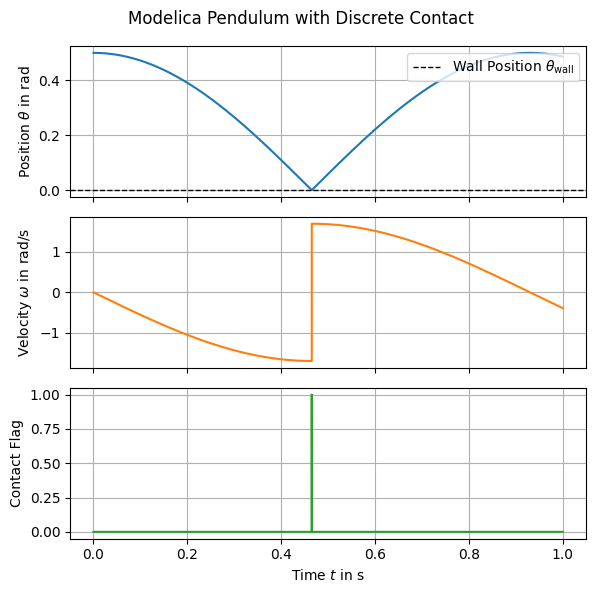

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
fig.suptitle("Modelica Pendulum with Discrete Contact")
axs[0].plot(t_ref, theta_ref, '-')
axs[0].axhline(theta_wall, color="k", linestyle="--", linewidth=1, label=r"Wall Position $\theta_{\text{wall}}$")
axs[0].set_ylabel(r"Position $\theta$ in rad")
axs[0].grid(True)
axs[0].legend(loc="upper right")

axs[1].plot(t_ref, omega_ref, color="tab:orange")
axs[1].set_ylabel(r"Velocity $\omega$ in rad/s")
axs[1].grid(True)

axs[2].step(t_ref, contact_ref.astype(int), where="post", color="tab:green")
axs[2].set_ylabel(r"Contact Flag")
axs[2].set_xlabel(r"Time $t$ in s")
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Export to FMU

We export two FMI 2.0 Co-Simulation FMUs from the same Modelica model:

- `cvode`
- `euler`

This keeps the physical model fixed while changing only the FMU solver/integration behavior.


In [55]:
modelica_cvode = ModelicaSystem(
    fileName=str(model_file),
    modelName="PendulumDiscreteContact",
    commandLineOptions=["--fmiFlags=s:cvode"],
)
modelica_cvode.buildModel()

modelica_euler = ModelicaSystem(
    fileName=str(model_file),
    modelName="PendulumDiscreteContact",
    commandLineOptions=["--fmiFlags=s:euler"],
)
modelica_euler.buildModel()

fmu_path_cvode = modelica_cvode.convertMo2Fmu(version="2.0", fmuType="cs")
fmu_path_euler = modelica_euler.convertMo2Fmu(version="2.0", fmuType="cs")

fmu_components = {
    "cvode": FMUComponent(name="PendulumCVODE", fmu_path=fmu_path_cvode),
    "euler": FMUComponent(name="PendulumEuler", fmu_path=fmu_path_euler),
}

[OMC log for 'sendExpression(buildModel(PendulumDiscreteContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(PendulumDiscreteContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(PendulumDiscreteContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulati

## FMU Simulation

Each FMU is simulated in `syssimx` with three macro communication step sizes (`dt = 0.01`, `dt = 0.001`, and `dt = 0.0001`).

This experiment demonstrates the key effect of this tutorial:

- larger macro `dt`: lower event-time observability accuracy
- smaller macro `dt`: better event detection accuracy, but more computational effort

The observed trend motivates the next tutorials, where event localization is improved with rollback and explicit hybrid event handling.

In [56]:
fmu_components = {
    "cvode": FMUComponent(name="PendulumCVODE", fmu_path=fmu_path_cvode),
    "euler": FMUComponent(name="PendulumEuler", fmu_path=fmu_path_euler),
}

dt_values = [1e-2, 1e-3, 1e-4]

fmu_results = {}

for solver_name, comp in fmu_components.items():
    fmu_results[solver_name] = {}
    for dt in dt_values:
        dt_results = {}
        comp.reset()
        comp.set_parameters(theta0=theta0, omega0=omega0)
        comp.initialize(t0=0.0)
        t_vals = np.arange(0.0, t_stop + dt, dt)
        for t in t_vals:
            comp.do_step(t, dt)
        history = comp.get_history()
        dt_results['theta'] = history['theta']
        dt_results['omega'] = history['omega']
        dt_results['contact'] = history['contact']
        fmu_results[solver_name][f"{dt}"] = dt_results

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

### Full Trajectory Comparison

The overview below shows the complete simulation window for all FMU configurations against the Modelica reference.

While the trajectories generally agree well between impacts, the accumulated timing errors after each contact lead to growing phase offsets — particularly visible for the coarser macro step sizes.

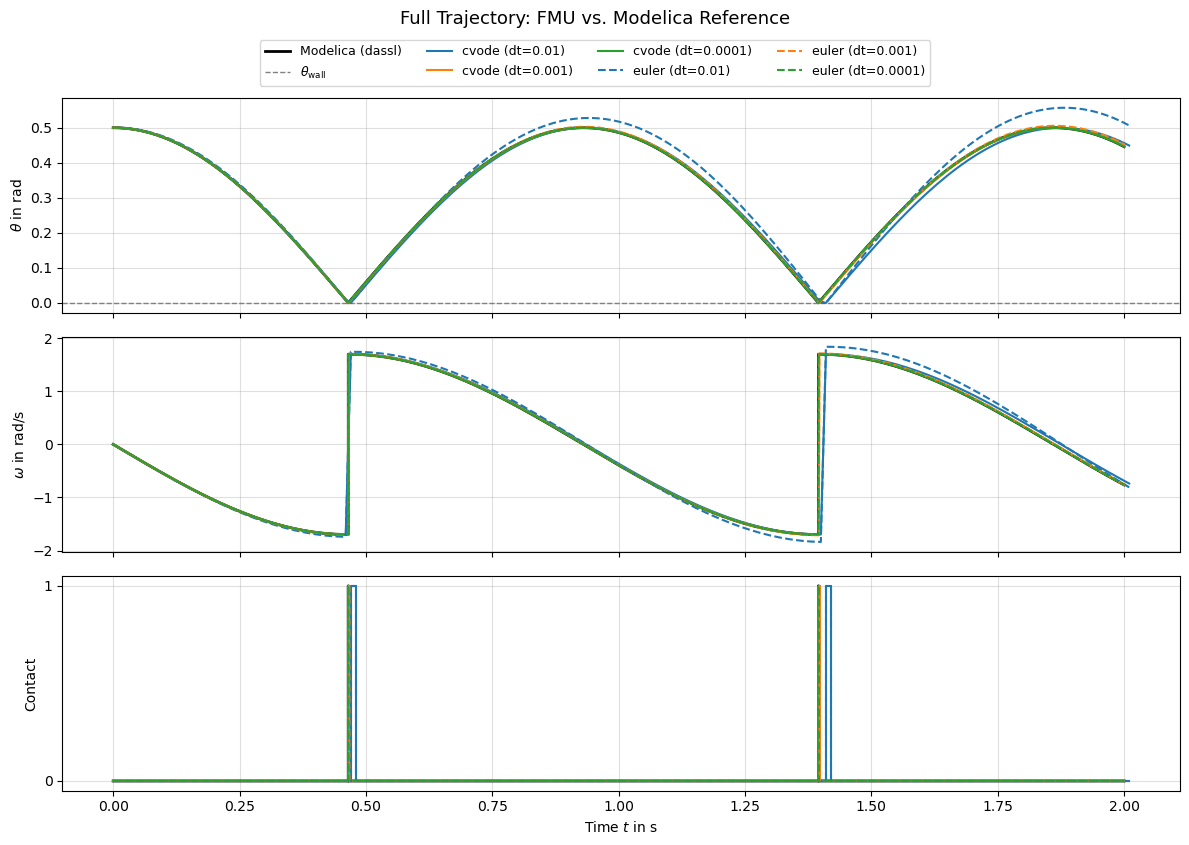

In [86]:
linestyles = {"euler": "dashed", "cvode": "solid"}
colors = {1e-2: "tab:blue", 1e-3: "tab:orange", 1e-4: "tab:green"}

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Full Trajectory: FMU vs. Modelica Reference", fontsize=13, y=1.05)

# --- Position ---
axs[0].plot(t_ref, theta_ref, color="black", linewidth=2, label="Modelica (dassl)")
axs[0].axhline(theta_wall, color="grey", linestyle="--", linewidth=1, label=r"$\theta_{\mathrm{wall}}$")
for solver_name, solver_results in fmu_results.items():
    for dt_str, results in solver_results.items():
        axs[0].plot(
            results["theta"]["time"], results["theta"]["values"],
            color=colors[float(dt_str)], linestyle=linestyles[solver_name],
            label=f"{solver_name} (dt={dt_str})",
        )
axs[0].set_ylabel(r"$\theta$ in rad")
axs[0].grid(True, alpha=0.4)

# --- Angular velocity ---
axs[1].plot(t_ref, omega_ref, color="black", linewidth=2)
for solver_name, solver_results in fmu_results.items():
    for dt_str, results in solver_results.items():
        axs[1].plot(
            results["omega"]["time"], results["omega"]["values"],
            color=colors[float(dt_str)], linestyle=linestyles[solver_name],
        )
axs[1].set_ylabel(r"$\omega$ in rad/s")
axs[1].grid(True, alpha=0.4)

# --- Contact flag ---
axs[2].step(t_ref, contact_ref.astype(int), where="post", color="black", linewidth=2)
for solver_name, solver_results in fmu_results.items():
    for dt_str, results in solver_results.items():
        axs[2].step(
            results["contact"]["time"], results["contact"]["values"].astype(int),
            where="post",
            color=colors[float(dt_str)], linestyle=linestyles[solver_name],
        )
axs[2].set_ylabel("Contact")
axs[2].set_xlabel(r"Time $t$ in s")
axs[2].set_yticks([0, 1])
axs[2].grid(True, alpha=0.4)

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02),
           ncol=len(labels)/2, fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

In [78]:
# --- Detect reference contact instants ---
t_ref_contact_vals = t_ref[np.where(contact_ref == 1)][::2]
t_contact_0 = t_ref_contact_vals[0]
t_contact_1 = t_ref_contact_vals[1]

print(f"Reference contact instants: t_0 = {t_contact_0:.6f} s, t_1 = {t_contact_1:.6f} s")

Reference contact instants: t_0 = 0.465078 s, t_1 = 1.395233 s


### Zoomed View: Contact Events

The plots below zoom into a narrow time window around each of the first two wall contacts.

Each column corresponds to one contact event. Within each column, the three rows show:

- **Position** $\theta(t)$: How closely the FMU trajectories track the Modelica reference near the wall.
- **Velocity** $\omega(t)$: The velocity reversal at impact — timing offsets are clearly visible here.
- **Contact flag**: The discrete event signal; delayed detection in FMU co-simulation shifts the flag to the right.

The black reference curve is the direct Modelica `dassl` solution with tight tolerances and internal root-finding.

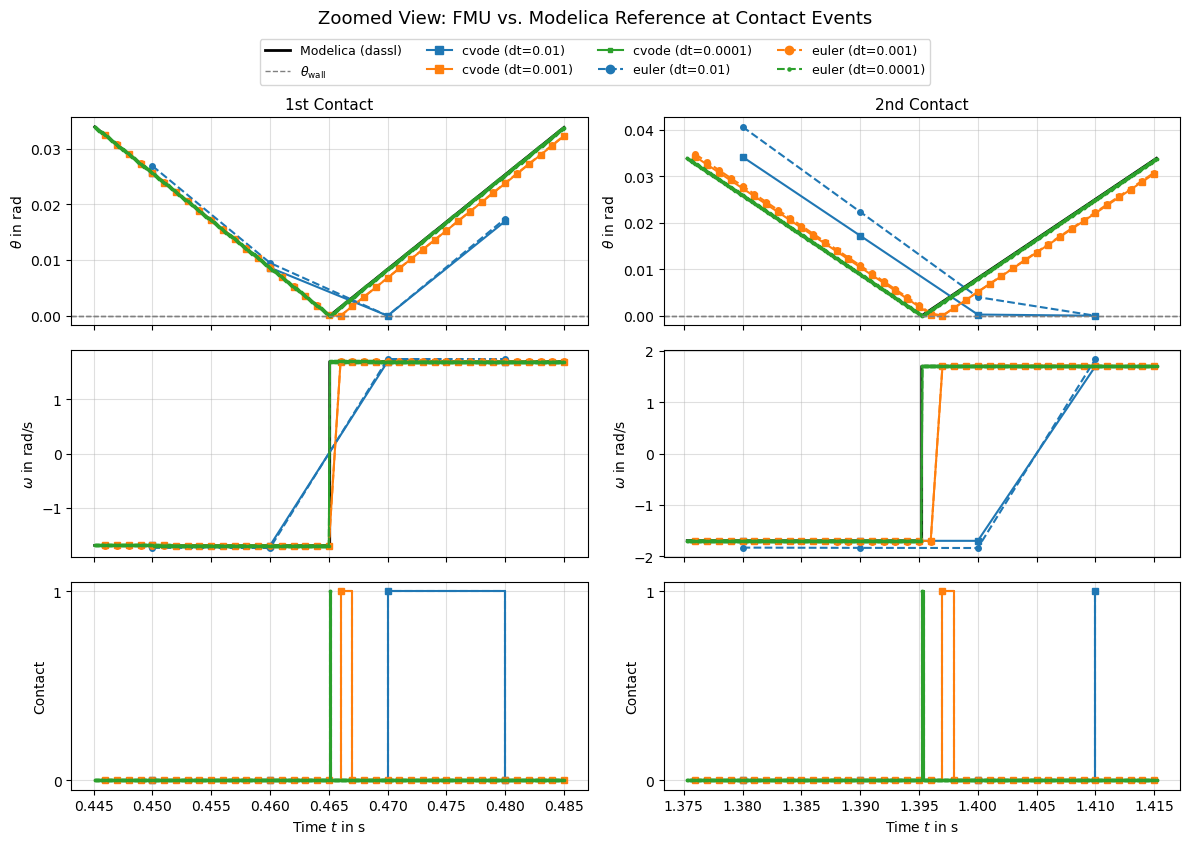

In [101]:
zoom = 0.02  # half-width of zoom window in seconds
contact_instants = [t_contact_0, t_contact_1]
contact_labels = ["1st Contact", "2nd Contact"]

fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex="col")
fig.suptitle("Zoomed View: FMU vs. Modelica Reference at Contact Events", fontsize=13, y=1.05)

markers = {"euler": "o", "cvode": "s"}

for col, (t_c, label) in enumerate(zip(contact_instants, contact_labels)):
    t_lo, t_hi = t_c - zoom, t_c + zoom
    mask_ref = (t_ref >= t_lo) & (t_ref <= t_hi)

    # --- Row 0: Position theta ---
    axs[0, col].plot(
        t_ref[mask_ref], theta_ref[mask_ref],
        color="black", linewidth=2, label="Modelica (dassl)",
    )
    axs[0, col].axhline(theta_wall, color="grey", linestyle="--", linewidth=1, label=r"$\theta_{\mathrm{wall}}$")
    for solver_name, solver_results in fmu_results.items():
        for dt_str, results in solver_results.items():
            t_vals = results["theta"]["time"]
            mask = (t_vals >= t_lo) & (t_vals <= t_hi)
            markersize = 1.5 if dt_str == "0.0001" else 4
            axs[0, col].plot(
                t_vals[mask], results["theta"]["values"][mask],
                color=colors[float(dt_str)],
                linestyle=linestyles[solver_name],
                label=f"{solver_name} (dt={dt_str})",
                marker=markers[solver_name], markersize=markersize
            )
    axs[0, col].axhline(theta_wall, color="grey", linestyle="--", linewidth=1)
    axs[0, col].set_title(label, fontsize=11)
    axs[0, col].set_ylabel(r"$\theta$ in rad")
    axs[0, col].grid(True, alpha=0.4)

    # --- Row 1: Angular velocity omega ---
    axs[1, col].plot(
        t_ref[mask_ref], omega_ref[mask_ref],
        color="black", linewidth=2,
    )
    for solver_name, solver_results in fmu_results.items():
        for dt_str, results in solver_results.items():
            t_vals = results["omega"]["time"]
            mask = (t_vals >= t_lo) & (t_vals <= t_hi)
            markersize = 1.5 if dt_str == "0.0001" else 4
            axs[1, col].plot(
                t_vals[mask], results["omega"]["values"][mask],
                color=colors[float(dt_str)],
                linestyle=linestyles[solver_name],
                marker=markers[solver_name], markersize=markersize
            )
    axs[1, col].set_ylabel(r"$\omega$ in rad/s")
    axs[1, col].grid(True, alpha=0.4)

    # --- Row 2: Contact flag ---
    axs[2, col].step(
        t_ref[mask_ref], contact_ref[mask_ref].astype(int),
        where="post", color="black", linewidth=2,
    )
    for solver_name, solver_results in fmu_results.items():
        for dt_str, results in solver_results.items():
            t_vals = results["contact"]["time"]
            mask = (t_vals >= t_lo) & (t_vals <= t_hi)
            markersize = 1.5 if dt_str == "0.0001" else 4
            axs[2, col].step(
                t_vals[mask], results["contact"]["values"][mask].astype(int),
                where="post",
                color=colors[float(dt_str)],
                linestyle=linestyles[solver_name],
                marker=markers[solver_name], markersize=markersize
            )
    axs[2, col].set_ylabel("Contact")
    axs[2, col].set_xlabel(r"Time $t$ in s")
    axs[2, col].set_yticks([0, 1])
    axs[2, col].grid(True, alpha=0.4)

# Shared legend (top of figure, no duplicates)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02),
           ncol=len(labels)/2, fontsize=9, frameon=True, markerscale=1.5)
plt.tight_layout()
plt.show()

We calculate the relative error compared to the Modelica reference solution for `theta`:

$$
\epsilon(t) = \frac{| \theta_{\text{FMU}}(t) - \theta_{\text{Modelica}}(t) |}{\max(|\theta_{\text{Modelica}}(t)|)}.
$$

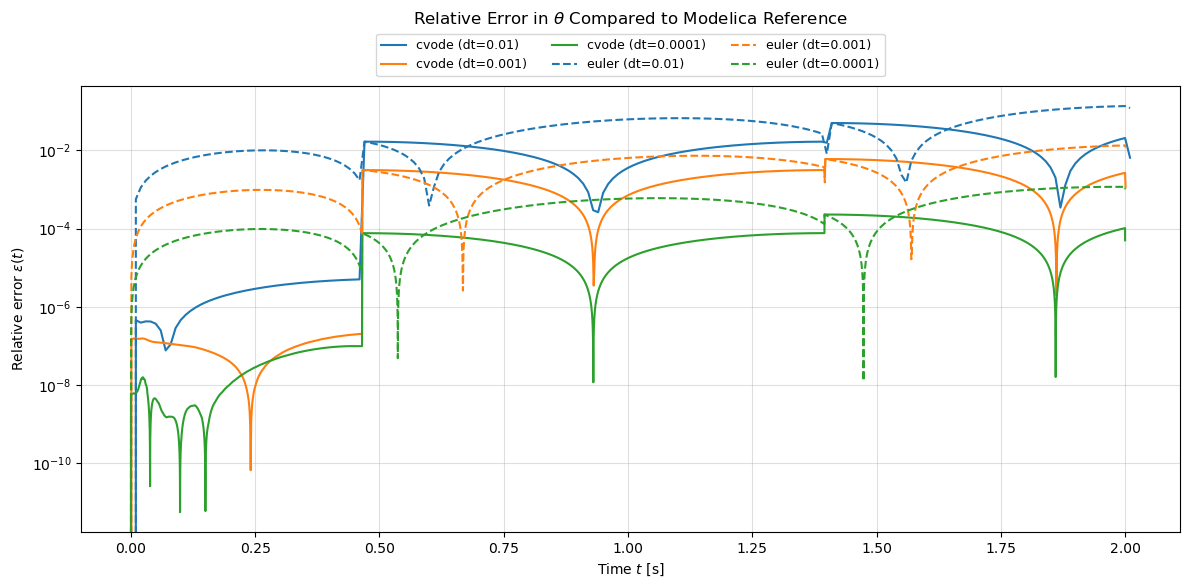

In [97]:
errors = {}
for solver_name, solver_results in fmu_results.items():
    errors[solver_name] = {}
    for dt_str, results in solver_results.items():
        t_vals = results["theta"]["time"]
        theta_vals = results["theta"]["values"]
        ref_interp = np.interp(t_vals, t_ref, theta_ref)
        errors[solver_name][dt_str] = np.abs(theta_vals - ref_interp) / np.max(np.abs(ref_interp))

fig, ax = plt.subplots(figsize=(12, 6))
for solver_name, solver_errors in errors.items():
    for dt_str, error in solver_errors.items():
        t_vals = fmu_results[solver_name][dt_str]["theta"]["time"]
        ax.semilogy(
            t_vals, error,
            color=colors[float(dt_str)], linestyle=linestyles[solver_name],
            label=f"{solver_name} (dt={dt_str})",
        )

ax.set_xlabel(r"Time $t$ [s]")
ax.set_ylabel(r"Relative error $\epsilon(t)$")
ax.set_title("Relative Error in $\\theta$ Compared to Modelica Reference", y=1.12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=3, fontsize=9, frameon=True)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Conclusion

This tutorial showed that FMUs containing Modelica state events are sensitive to macro communication step size when used in co-simulation.

A smaller `dt` is typically required to detect impact events with high timing accuracy if no additional localization strategy is used.

In the following tutorials, we extend the `FMUComponent` workflow in `syssimx` with rollback and event-handling capabilities to localize events more accurately without relying only on globally small macro steps.
